# ReAct Architecture of agents

In [1]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient
import json

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-Agent"

C:\Users\Asus\AppData\Local\Temp\ipykernel_25564\113487486.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun
C:\Users\Asus\AppData\Local\Temp\ipykernel_25564\113487486.py:18: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


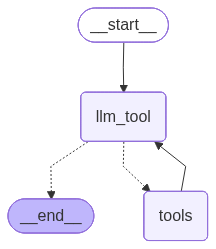

In [2]:
# Libraries
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from typing import Annotated
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langchain_community.tools.tavily_search import TavilySearchResults

# tools list

wiki_wrapper = WikipediaAPIWrapper(top_k_results=1)
wiki = WikipediaQueryRun(api_wrapper=wiki_wrapper)

tavily_tool = TavilySearchResults(
    max_results = 2
)

def add_numbers(a:int, b:int) -> int:
    """
    Function to sum two numbers and their their sum

    Args:
        a (int): First number
        b (int): Second Number

    Return:
        int: sum of a and b

    """
    return a + b


def multiply_numbers(a:int, b:int) -> int:
    """
    Function to multiply two numbers and their their multiplication

    Args:
        a (int): First number
        b (int): Second Number

    Return:
        int: multiplication of a and b

    """
    return a * b

def divide_numbers(a:int, b:int) -> int:
    """
    Function to divide two numbers and their their division

    Args:
        a (int): First number
        b (int): Second Number

    Return:
        int: division of a and b

    """
    return a / b

# tools list
tools = [wiki, tavily_tool, add_numbers, multiply_numbers, divide_numbers]

# Model defination
model = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature=0
)

# binding models with tools
model_with_tools = model.bind_tools(tools)

# Graph State
class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

# model node
def llm_tool(state:State):
    return {"messages": model_with_tools.invoke(state.messages)}

# graph structure
graph = StateGraph(State)

# nodes
graph.add_node("llm_tool", llm_tool)
graph.add_node("tools", ToolNode(tools=tools))

# egdes
graph.add_edge(START, "llm_tool")
graph.add_conditional_edges("llm_tool", tools_condition)
graph.add_edge("tools", "llm_tool")
# graph.add_edge("llm_tool", END)

# compiling the graph
graph_builder = graph.compile()

# view the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [3]:
# invoking the graph
response = graph_builder.invoke({"messages": "Provide me latest AI News on 14th June 2026. And then multiply 5 * 5 and then add 20."})
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Provide me latest AI News on 14th June 2026. And then multiply 5 * 5 and then add 20.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (by39hncnj)
 Call ID: by39hncnj
  Args:
    query: AI News 14th June 2026
  multiply_numbers (sdcc7rj0y)
 Call ID: sdcc7rj0y
  Args:
    a: 5
    b: 5
  add_numbers (5kg99s3r7)
 Call ID: 5kg99s3r7
  Args:
    a: 25
    b: 20
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Today - June 15, 2026: 16 Biggest Stories", "url": "https://www.buildfastwithai.com/blogs/ai-news-today-june-15-2026", "content": "The practical guidance for enterprise teams, per CosmicJS's developer action plan (June 14, 2026): current sessions that were routing to Fable 5 will end in errors and new queries will automatically route to older, less

## Memory Saver

In [ ]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="multiply that to 60")]
response = graph_builder.invoke({"messages": messages})
for message in response["messages"]:
    message.pretty_print()